In [56]:
import numpy as np
import torch
import torch.nn as nn
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Set seed for reproducibility (crucial for consistent plots in the report)
np.random.seed(42)
torch.manual_seed(42)
print("Libraries imported and random seeds set.")

Libraries imported and random seeds set.


In [57]:
# Data Generation (Sparse & Noisy)
def damped_oscillator(t, y, c=0.3, k=1.0):
    q, p = y
    return [p, -k*q - c*p]

t_span = (0, 15)
t_eval = np.linspace(0, 15, 1000)
y0 = [1.0, 0.0]

# Ground truth
sol = solve_ivp(damped_oscillator, t_span, y0, t_eval=t_eval)
q_true, p_true = sol.y
dqdt_true, dpdt_true = p_true, -1.0 * q_true - 0.3 * p_true

# Subsample and add noise to simulate poor sensor data
num_samples = 80
noise_level = 0.05

sparse_idx = np.random.choice(len(t_eval), num_samples, replace=False)
q_sparse, p_sparse = q_true[sparse_idx], p_true[sparse_idx]
dq_sparse, dp_sparse = dqdt_true[sparse_idx], dpdt_true[sparse_idx]

q_train = q_sparse + np.random.randn(num_samples) * noise_level
p_train = p_sparse + np.random.randn(num_samples) * noise_level
dq_train = dq_sparse + np.random.randn(num_samples) * noise_level
dp_train = dp_sparse + np.random.randn(num_samples) * noise_level

x_data = torch.tensor(np.stack([q_train, p_train], axis=1), dtype=torch.float32, requires_grad=True)
dxdt_data = torch.tensor(np.stack([dq_train, dp_train], axis=1), dtype=torch.float32)

print(f"Data generated. Training tensor shape: {x_data.shape}")

Data generated. Training tensor shape: torch.Size([80, 2])


In [ ]:
# Model Architectures
class DampedHNN(nn.Module):
    def __init__(self):
        super().__init__()
        # MLP to approximate Hamiltonian H(q, p)
        self.h_net = nn.Sequential(
            nn.Linear(2, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )
        # Learnable damping parameter
        self.c = nn.Parameter(torch.tensor([0.0]))

    def forward(self, x):
        H = self.h_net(x)
        
        # Compute spatial gradients via autograd
        dH_dx = torch.autograd.grad(H.sum(), x, create_graph=True)[0]
        dH_dq, dH_dp = dH_dx[:, 0], dH_dx[:, 1]
        
        # Apply modified Hamilton's equations with dissipation
        dqdt = dH_dp
        dpdt = -dH_dq - self.c * dH_dp
        return torch.stack([dqdt, dpdt], dim=1)

class BaselineMLP(nn.Module): 
    def __init__(self):
        super().__init__()
        # Standard black-box mapping without physical constraints
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.net(x)

print("Model architectures defined successfully.")

Model architectures defined successfully.


In [59]:
# raining Loop
hnn_model = DampedHNN()
base_model = BaselineMLP()

opt_hnn = torch.optim.Adam(hnn_model.parameters(), lr=1e-3)
opt_base = torch.optim.Adam(base_model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

epochs = 5000

print("Starting training...")
for ep in range(epochs):
    # Train Damped HNN
    opt_hnn.zero_grad()
    loss_hnn = criterion(hnn_model(x_data), dxdt_data)
    loss_hnn.backward()
    opt_hnn.step()
    
    # Train Baseline MLP
    opt_base.zero_grad()
    loss_base = criterion(base_model(x_data), dxdt_data)
    loss_base.backward()
    opt_base.step()
    
    if ep % 1000 == 0 or ep == epochs - 1:
        print(f"Epoch {ep:4d} | HNN Loss: {loss_hnn.item():.4f} (c={hnn_model.c.item():.4f}) | Base Loss: {loss_base.item():.4f}")

Starting training...
Epoch    0 | HNN Loss: 0.1189 (c=0.0010) | Base Loss: 0.1432
Epoch 1000 | HNN Loss: 0.0051 (c=0.2804) | Base Loss: 0.0053
Epoch 2000 | HNN Loss: 0.0044 (c=0.2895) | Base Loss: 0.0052
Epoch 3000 | HNN Loss: 0.0044 (c=0.2907) | Base Loss: 0.0046
Epoch 4000 | HNN Loss: 0.0043 (c=0.2945) | Base Loss: 0.0040
Epoch 4999 | HNN Loss: 0.0043 (c=0.2977) | Base Loss: 0.0034


Integrating learned vector fields... (this may take a few seconds)


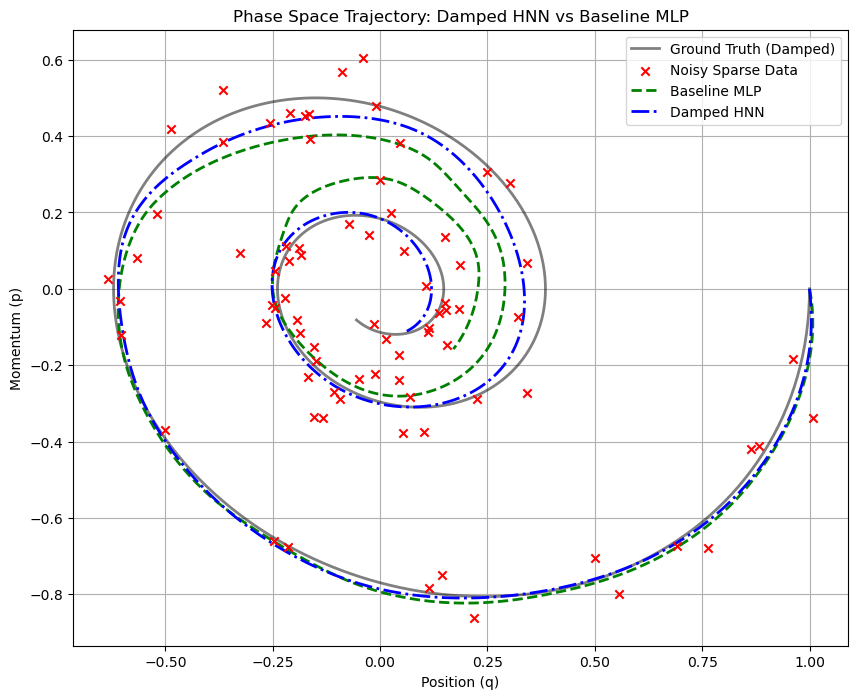

In [60]:
# Evaluation & Plotting

def get_hnn_grad(t, y):
    yt = torch.tensor(y, dtype=torch.float32, requires_grad=True).unsqueeze(0)
    return hnn_model(yt).detach().numpy()[0]

def get_base_grad(t, y):
    yt = torch.tensor(y, dtype=torch.float32).unsqueeze(0)
    return base_model(yt).detach().numpy()[0]

# Integrate learned vector fields
print("Integrating learned vector fields... (this may take a few seconds)")
sol_hnn = solve_ivp(get_hnn_grad, t_span, y0, t_eval=t_eval)
sol_base = solve_ivp(get_base_grad, t_span, y0, t_eval=t_eval)

# Plot Phase Space
plt.figure(figsize=(10, 8))
plt.plot(q_true, p_true, 'k-', alpha=0.5, label='Ground Truth (Damped)', lw=2)
plt.scatter(x_data[:, 0].detach().numpy(), x_data[:, 1].detach().numpy(), c='red', marker='x', label='Noisy Sparse Data', zorder=5)
plt.plot(sol_base.y[0], sol_base.y[1], 'g--', label='Baseline MLP', lw=2)
plt.plot(sol_hnn.y[0], sol_hnn.y[1], 'b-.', label='Damped HNN', lw=2)

plt.title("Phase Space Trajectory: Damped HNN vs Baseline MLP")
plt.xlabel("Position (q)")
plt.ylabel("Momentum (p)")
plt.legend()
plt.grid(True)
plt.show()